# Batch preview — junction decision z biblioteki

Ten notebook używa implementacji z `coronary_analysis` zamiast duplikować logikę z notebooka.

Pipeline:

1. wczytuje obraz i maskę,
2. czyści maskę przez `coronary_analysis.topology.preprocessing.clean_mask`,
3. szkieletyzuje i przycina skeleton przez `coronary_analysis.topology.skeleton`,
4. liczy distance map przez `coronary_analysis.topology.diameter.compute_distance_map`,
5. klasyfikuje junctions przez `coronary_analysis.topology.junction_decision.junction_decision.run_junction_decision`,
6. rysuje dwa osobne wykresy:
   - wszystkie etykiety: `certain / false / not`,
   - tylko `certain`.

Konfiguracja junction decision pochodzi z bibliotecznego `DEFAULT_JUNCTION_DECISION_CONFIG`, czyli z pliku config używanego przez bibliotekę.


In [3]:
from __future__ import annotations

from pathlib import Path
import random
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "coronary-analysis" / "src"

if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

In [4]:
from coronary_analysis.topology.diameter import compute_distance_map
from coronary_analysis.topology.junction_decision.classifier import (
    run_junction_decision,
)
from coronary_analysis.topology.junction_decision.model import (
    DEFAULT_JUNCTION_DECISION_CONFIG,
    JunctionDecision,
    JunctionLabel,
)
from coronary_analysis.topology.preprocessing import clean_mask
from coronary_analysis.topology.skeleton import prune_skeleton, skeletonize_mask

## Config

In [ ]:
DATA_ROOT = Path("raw_datasets")
USE_GROUND_TRUTH = True

N_RANDOM_SAMPLES = 10
RANDOM_SEED = 42

# Notebook-level preprocessing / preview settings.
# Junction decision thresholds are intentionally not duplicated here.
MASK_CLOSING_RADIUS = 2
MASK_MAX_HOLE_SIZE = 50
MASK_MIN_OBJECT_SIZE = 30
PRUNE_MIN_BRANCH_LENGTH = 15

JUNCTION_DECISION_CONFIG = DEFAULT_JUNCTION_DECISION_CONFIG
JUNCTION_DECISION_CONFIG

JunctionDecisionConfig(junction_group_dilation=3, min_junction_area=1, remove_radius=2, max_arm_steps=60, min_arm_len=4, enable_local_refine=True, local_crop_size=80, local_remove_radius=2, local_max_arm_steps=80, local_min_arm_len=2, local_keep_short_arms=True, local_prune_min_branch_length=2, fake_mean_cost_threshold=0.25, fake_max_cost_threshold=0.4, allow_two_arm_fake=True, min_area_for_two_arm_fake=6, enable_thickness_fake=True, thickness_radius=5, thickness_fake_threshold=2.0, thickness_fake_max_extra=1.0, thickness_area_threshold=4, soft_false_mean_cost_extra=0.15, graph_cleanup_neighbor_score_threshold=0.3, max_pairing_arms=8, graph_cleanup_max_center_distance=8.0)

## Data loading

In [5]:
def scan_pgm_dataset(root=DATA_ROOT):
    root = Path(root)
    images = {}
    masks = {}

    for p in root.rglob("*.pgm"):
        stem = p.stem
        low = stem.lower()

        is_mask = (
            stem.endswith("_gt")
            or stem.endswith("_manual1")
            or stem.endswith("_manual")
            or "manual" in low
            or low.endswith("gt")
            or "_gt" in low
        )

        if is_mask:
            key = stem.replace("_gt", "").replace("_manual1", "").replace("_manual", "")
            masks[key] = p
        else:
            images[stem] = p

    rows = []
    for key, img_path in images.items():
        rows.append(
            {
                "id": key,
                "image_path": img_path,
                "mask_path": masks.get(key),
                "has_mask": key in masks,
            }
        )

    return sorted(rows, key=lambda x: str(x["image_path"]))


def read_gray(path):
    arr = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if arr is None:
        raise FileNotFoundError(f"Nie można wczytać: {path}")
    return arr


def make_fallback_mask(image):
    blur = cv2.GaussianBlur(image, (5, 5), 0)
    return cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1] > 0


def load_sample_by_index(sample_index, samples, use_ground_truth=True):
    row = samples[sample_index]
    image = read_gray(row["image_path"])

    if use_ground_truth and row["mask_path"] is not None:
        raw_mask = read_gray(row["mask_path"]) > 0
    else:
        raw_mask = make_fallback_mask(image)

    return image, raw_mask, row


samples = scan_pgm_dataset(DATA_ROOT)
print("Found samples:", len(samples))
display(pd.DataFrame(samples).head(20))

Found samples: 134


,id,image_path,mask_path,has_mask
0,109,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
1,110,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
2,115,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
3,116,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
4,132,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
5,15,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
6,22,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
7,26,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
8,31,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True
9,37,raw_datasets/DCA1/Database_134_Angiograms/test...,raw_datasets/DCA1/Database_134_Angiograms/test...,True


# Pipeline for sample

In [9]:
def run_pipeline_for_sample(sample_index: int) -> dict:
    image, raw_mask, row = load_sample_by_index(sample_index, samples, USE_GROUND_TRUTH)

    mask_clean = clean_mask(
        raw_mask,
        closing_radius=MASK_CLOSING_RADIUS,
        max_hole_size=MASK_MAX_HOLE_SIZE,
        min_object_size=MASK_MIN_OBJECT_SIZE,
    ).astype(bool)

    skeleton_raw = skeletonize_mask(mask_clean).astype(bool)
    skeleton_pruned = prune_skeleton(
        skeleton_raw,
        min_branch_length=PRUNE_MIN_BRANCH_LENGTH,
    ).astype(bool)

    distance_map = compute_distance_map(mask_clean)

    junction_decision = run_junction_decision(
        image=image,
        mask_clean=mask_clean,
        skeleton=skeleton_pruned,
        distance_map=distance_map,
        config=JUNCTION_DECISION_CONFIG,
    )

    return {
        "image": image,
        "mask_clean": mask_clean,
        "skeleton": skeleton_pruned,
        "junction_groups": junction_decision.junction_groups,
        "all_junction_pixel_mask": junction_decision.all_junction_pixel_mask,
        "junction_decision": junction_decision,
        "results": junction_decision.decisions,
        "row": row,
    }


def summarize_labels(results: list[JunctionDecision]) -> dict[str, int]:
    counts = {label.value: 0 for label in JunctionLabel}
    for decision in results:
        counts[decision.label.value] += 1
    return counts

In [10]:
def _arm_path(arm):
    if isinstance(arm, dict):
        return arm["path"]
    return arm.path


def _plot_junctions_on_axis(
    ax,
    sample_out: dict,
    *,
    mode: str = "all",
    title_prefix: str = "",
) -> None:
    image = sample_out["image"]
    skeleton = sample_out["skeleton"]
    results = sample_out["results"]
    row = sample_out["row"]

    ax.imshow(image, cmap="gray")

    ys, xs = np.where(skeleton > 0)
    ax.scatter(xs, ys, s=1, c="white", alpha=0.65)

    colors = {
        JunctionLabel.CERTAIN.value: "lime",
        JunctionLabel.FALSE.value: "orange",
        JunctionLabel.NOT.value: "deepskyblue",
    }

    for idx, decision in enumerate(results):
        label = decision.label.value
        if mode == "certain_only" and decision.label is not JunctionLabel.CERTAIN:
            continue

        cy, cx = decision.center
        color = colors.get(label, "yellow")

        ax.scatter([cx], [cy], s=120, facecolors="none", edgecolors=color, linewidths=3)

        suffix = "L" if decision.used_local_reskeleton else ""
        label_text = f"{idx}:{label}{suffix}"

        ax.text(cx + 3, cy - 3, label_text, color=color, fontsize=10, weight="bold")

        for arm in decision.arms:
            path = _arm_path(arm)
            ax.plot(path[:, 1], path[:, 0], linewidth=1.2, alpha=0.75)

    counts = summarize_labels(results)

    if mode == "all":
        title = (
            f"{title_prefix} ALL LABELS | sample={row['id']} | "
            f"certain={counts['certain']} false={counts['false']} not={counts['not']}"
        )
    else:
        title = (
            f"{title_prefix} ONLY CERTAIN | sample={row['id']} | "
            f"certain={counts['certain']}"
        )

    ax.set_title(title)
    ax.axis("off")


def plot_junctions(sample_out: dict, mode: str = "all", title_prefix: str = "") -> None:
    plt.figure(figsize=(10, 10))
    ax = plt.gca()
    _plot_junctions_on_axis(
        ax,
        sample_out,
        mode=mode,
        title_prefix=title_prefix,
    )
    plt.show()


def plot_junctions_pair(sample_out: dict, title_prefix: str = "") -> None:
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    _plot_junctions_on_axis(
        axes[0],
        sample_out,
        mode="all",
        title_prefix=title_prefix,
    )

    _plot_junctions_on_axis(
        axes[1],
        sample_out,
        mode="certain_only",
        title_prefix=title_prefix,
    )

    plt.tight_layout()
    plt.show()

## 8. Examples

Selected sample indices: [1, 16, 21, 127, 100, 103, 31, 30, 36, 76]


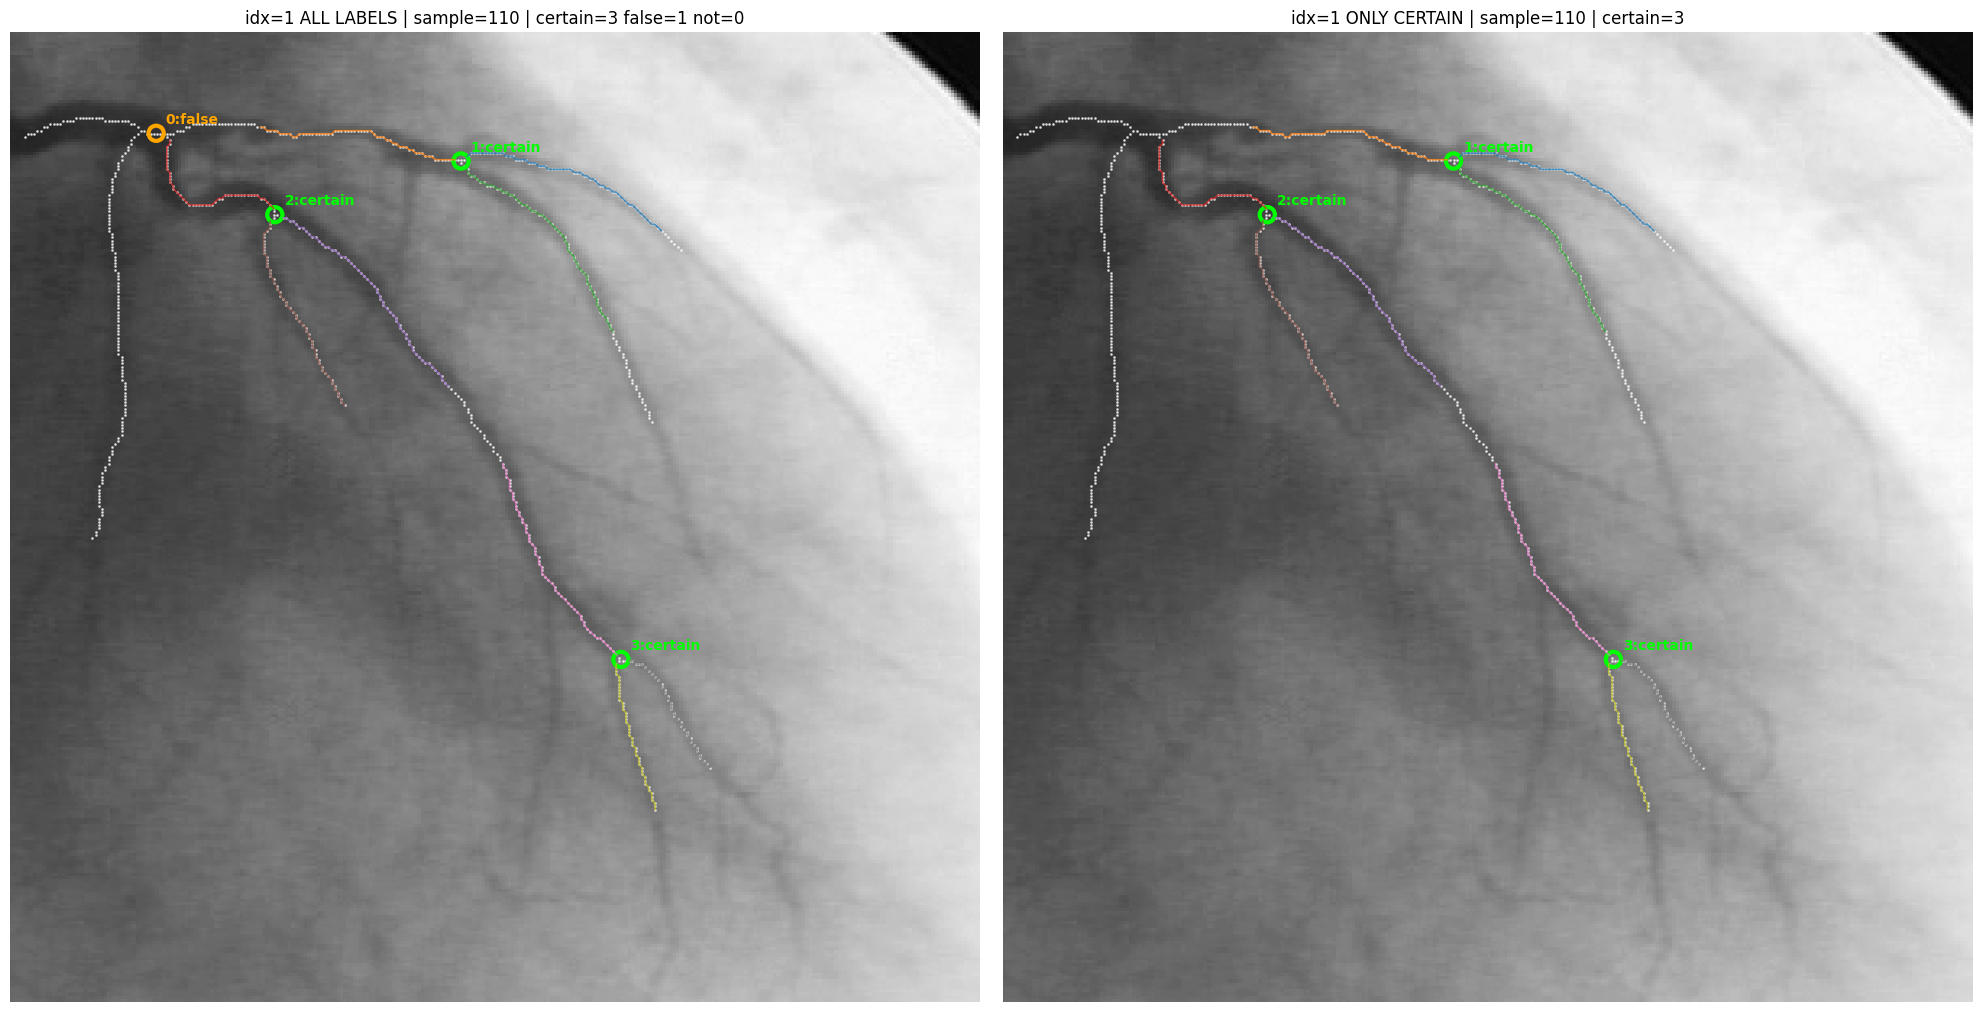

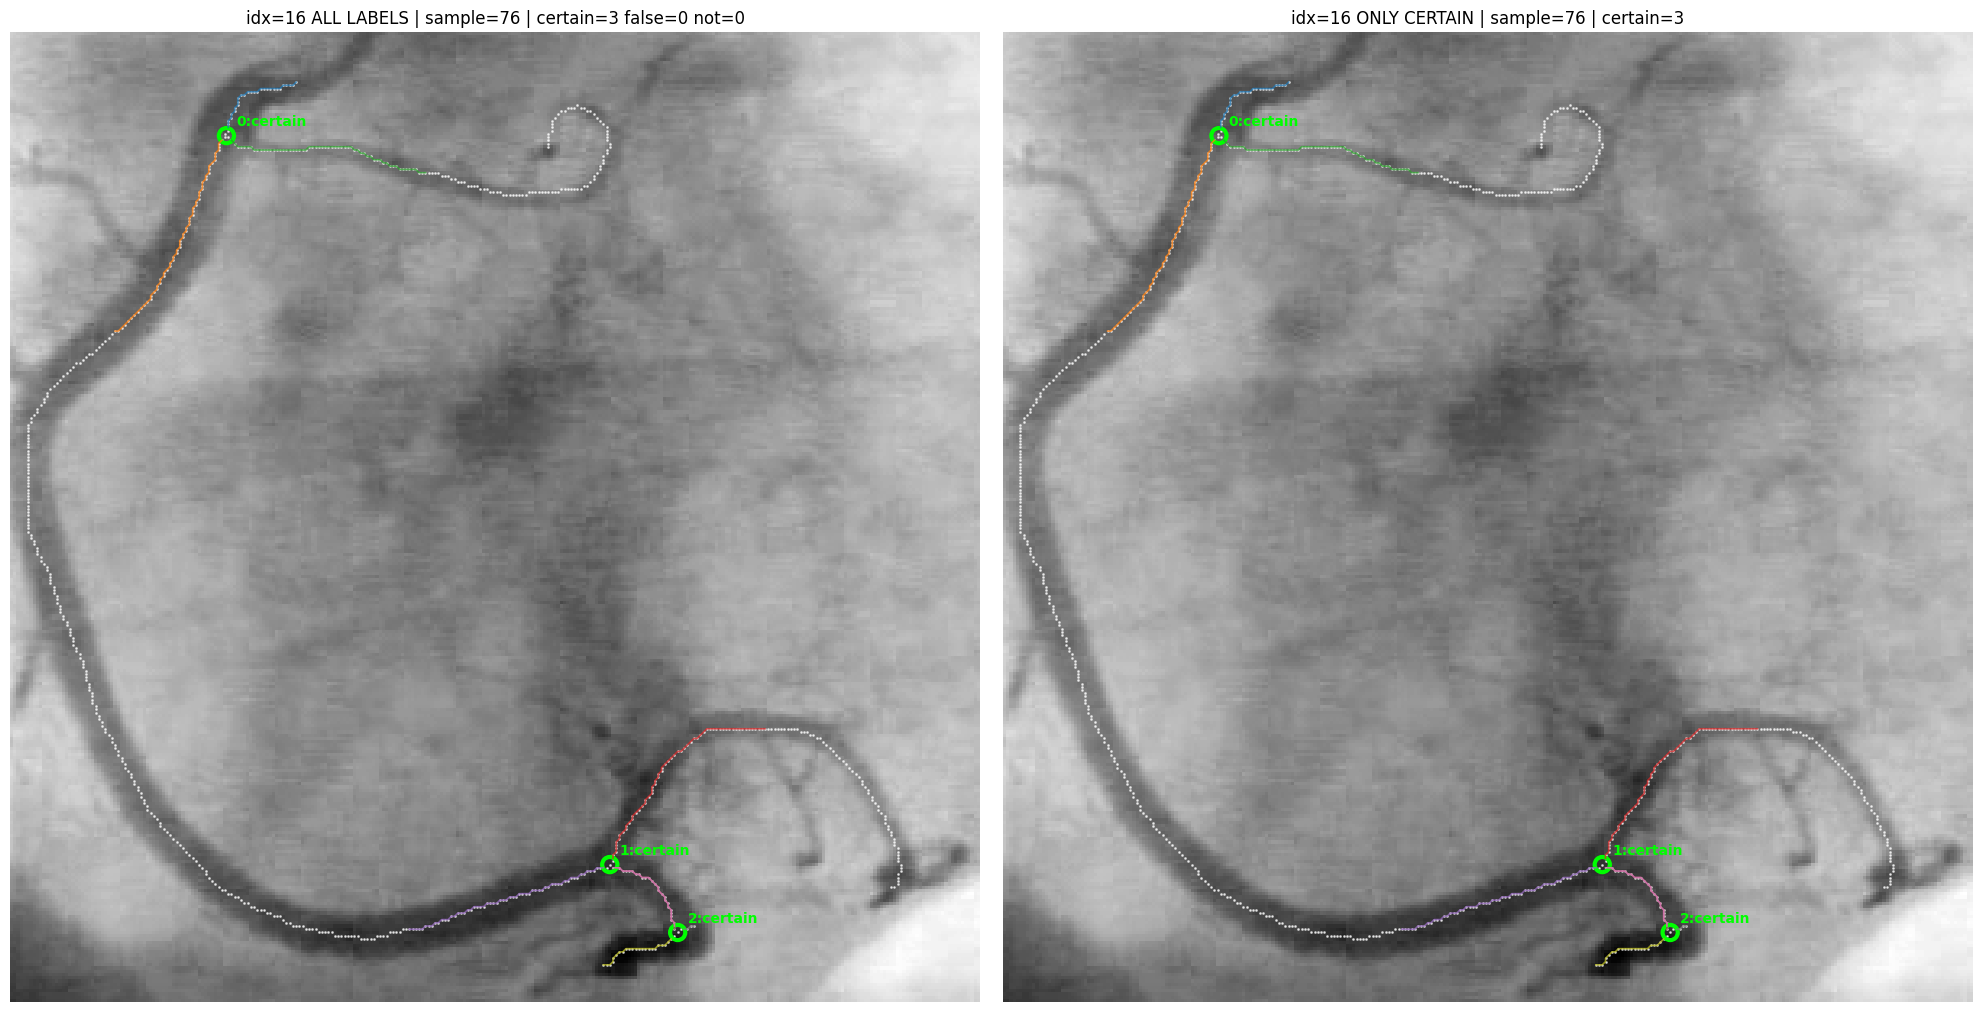

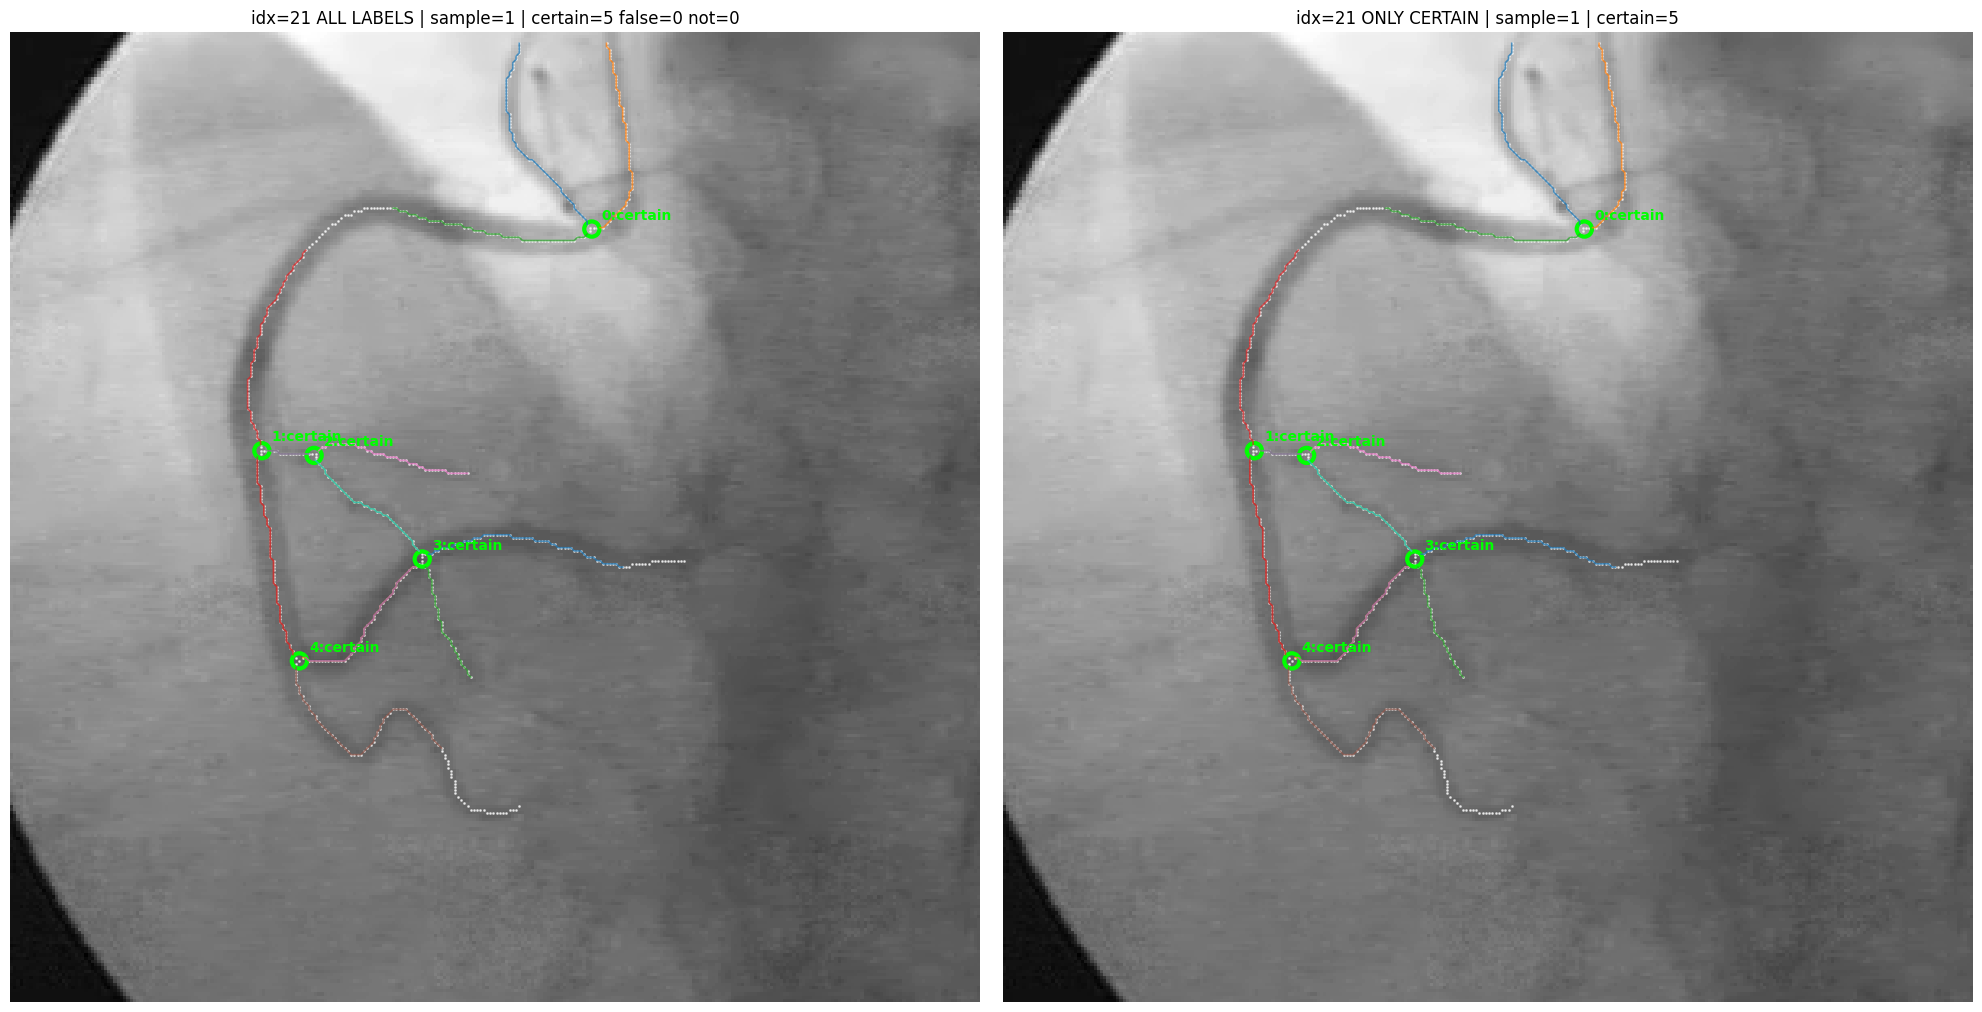

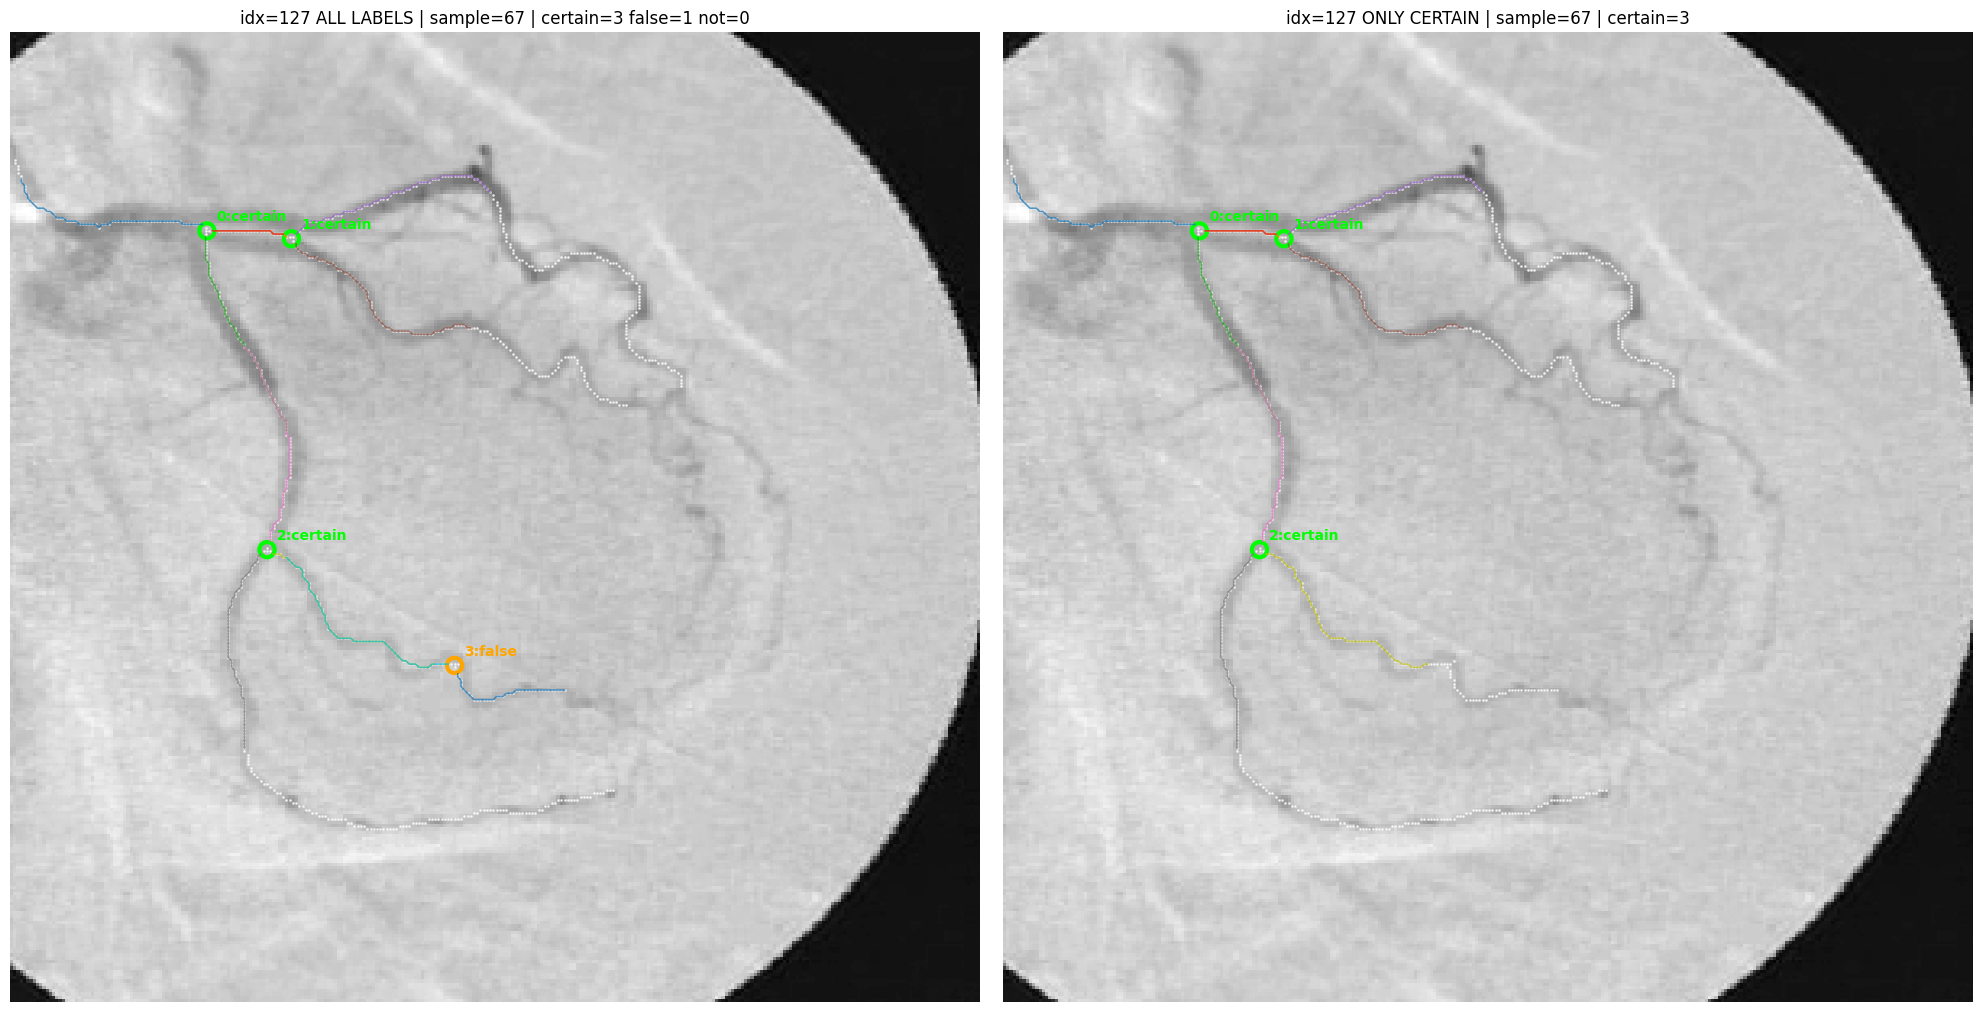

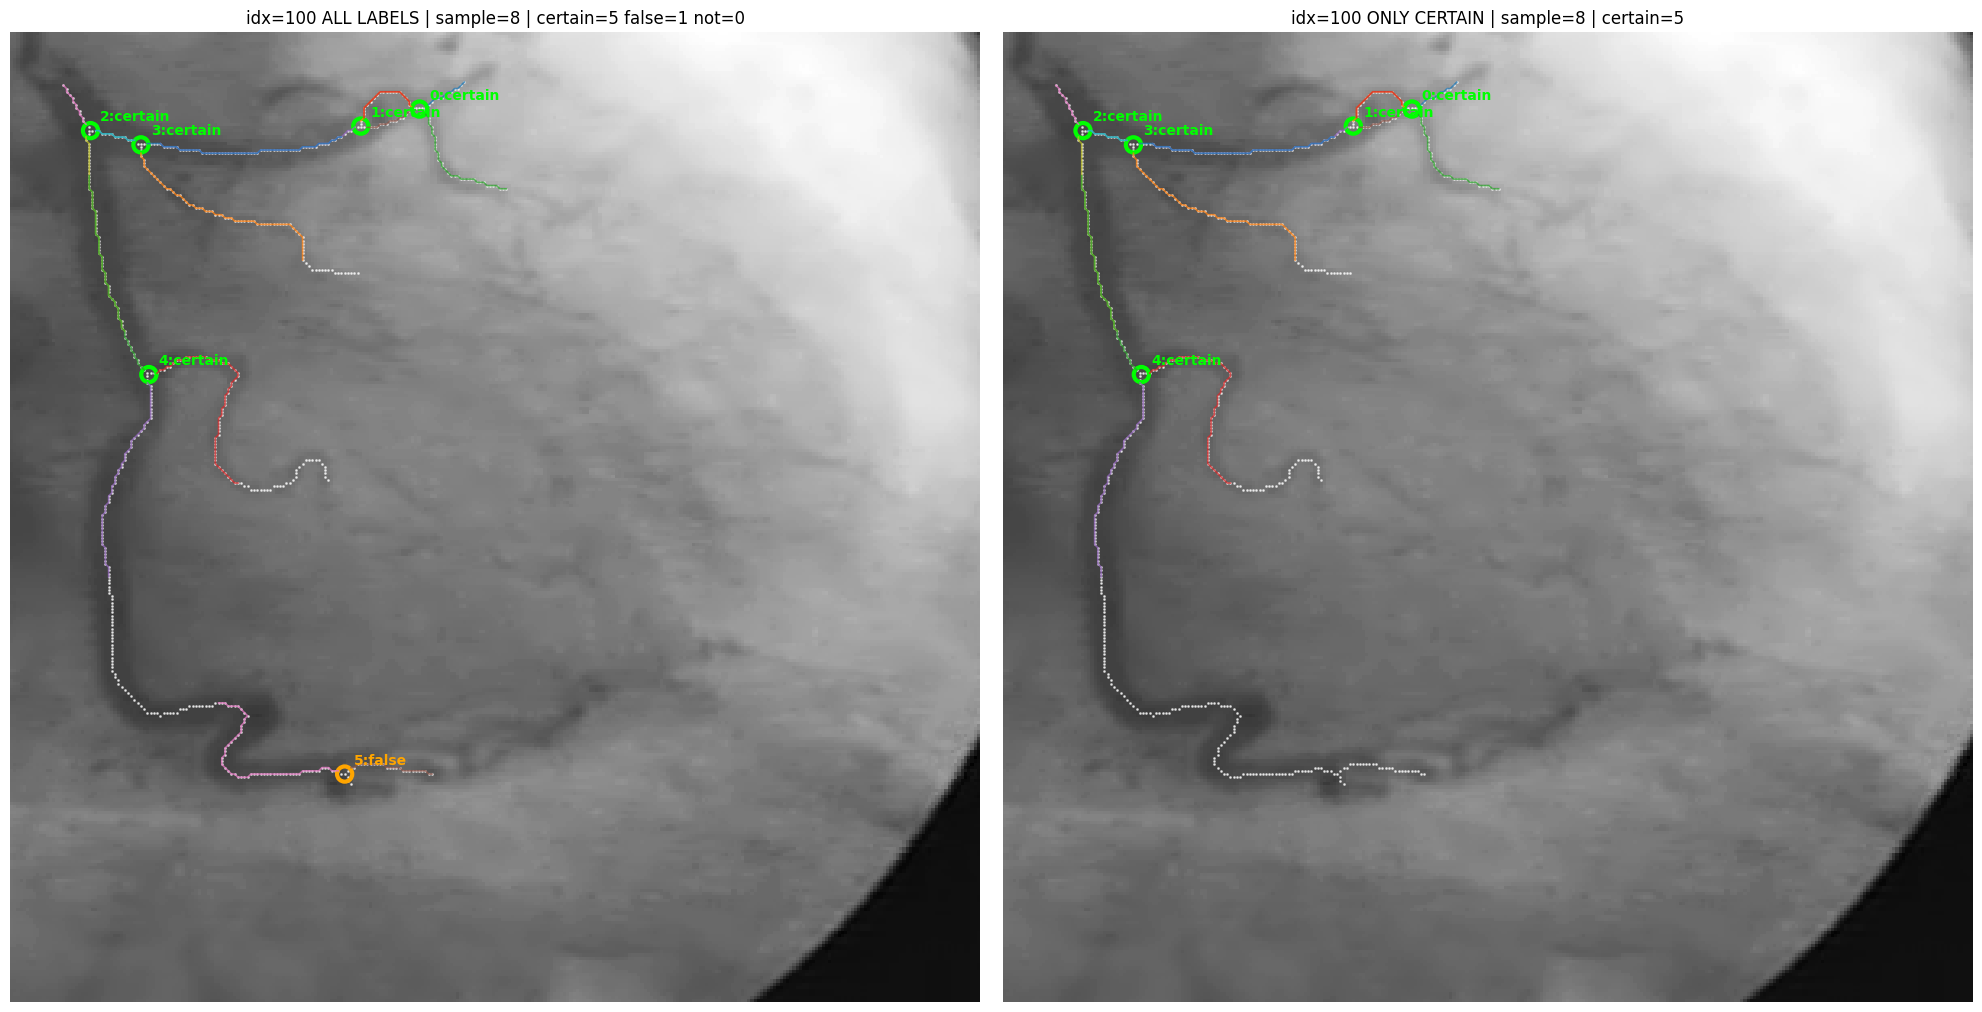

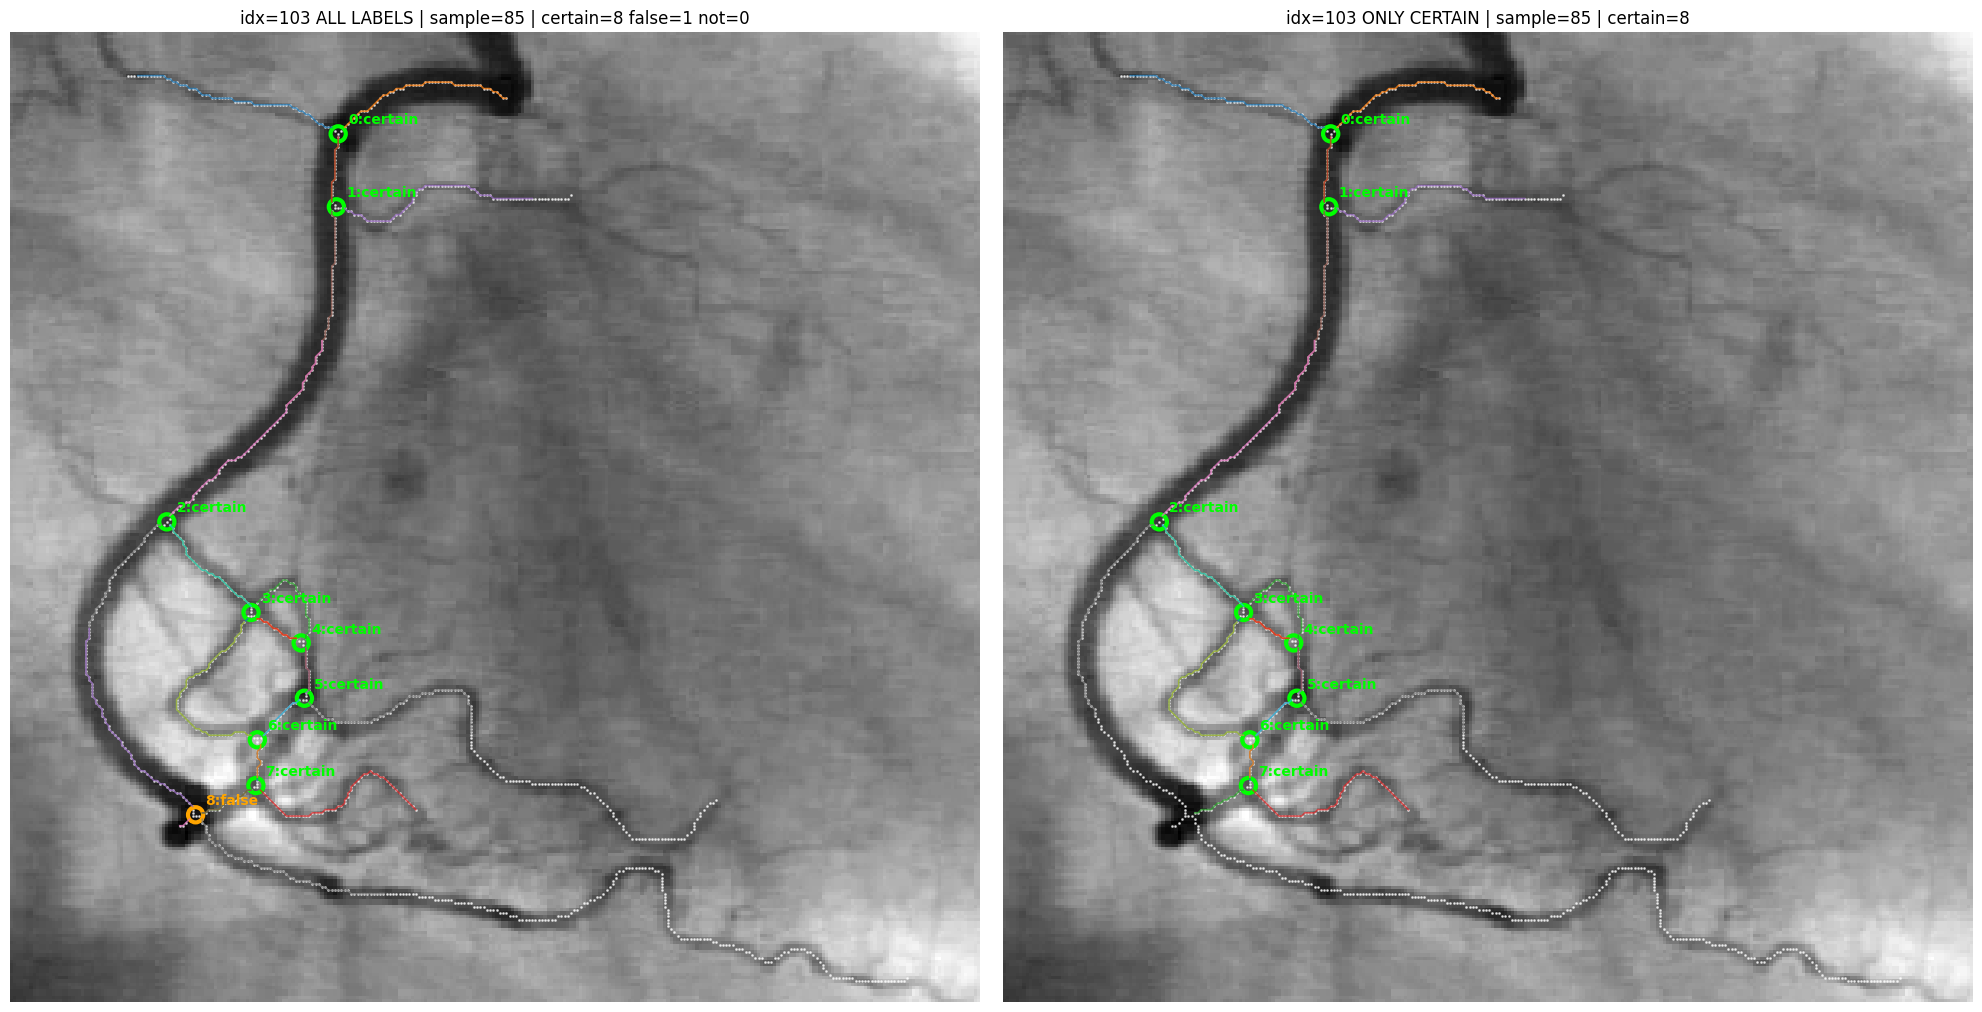

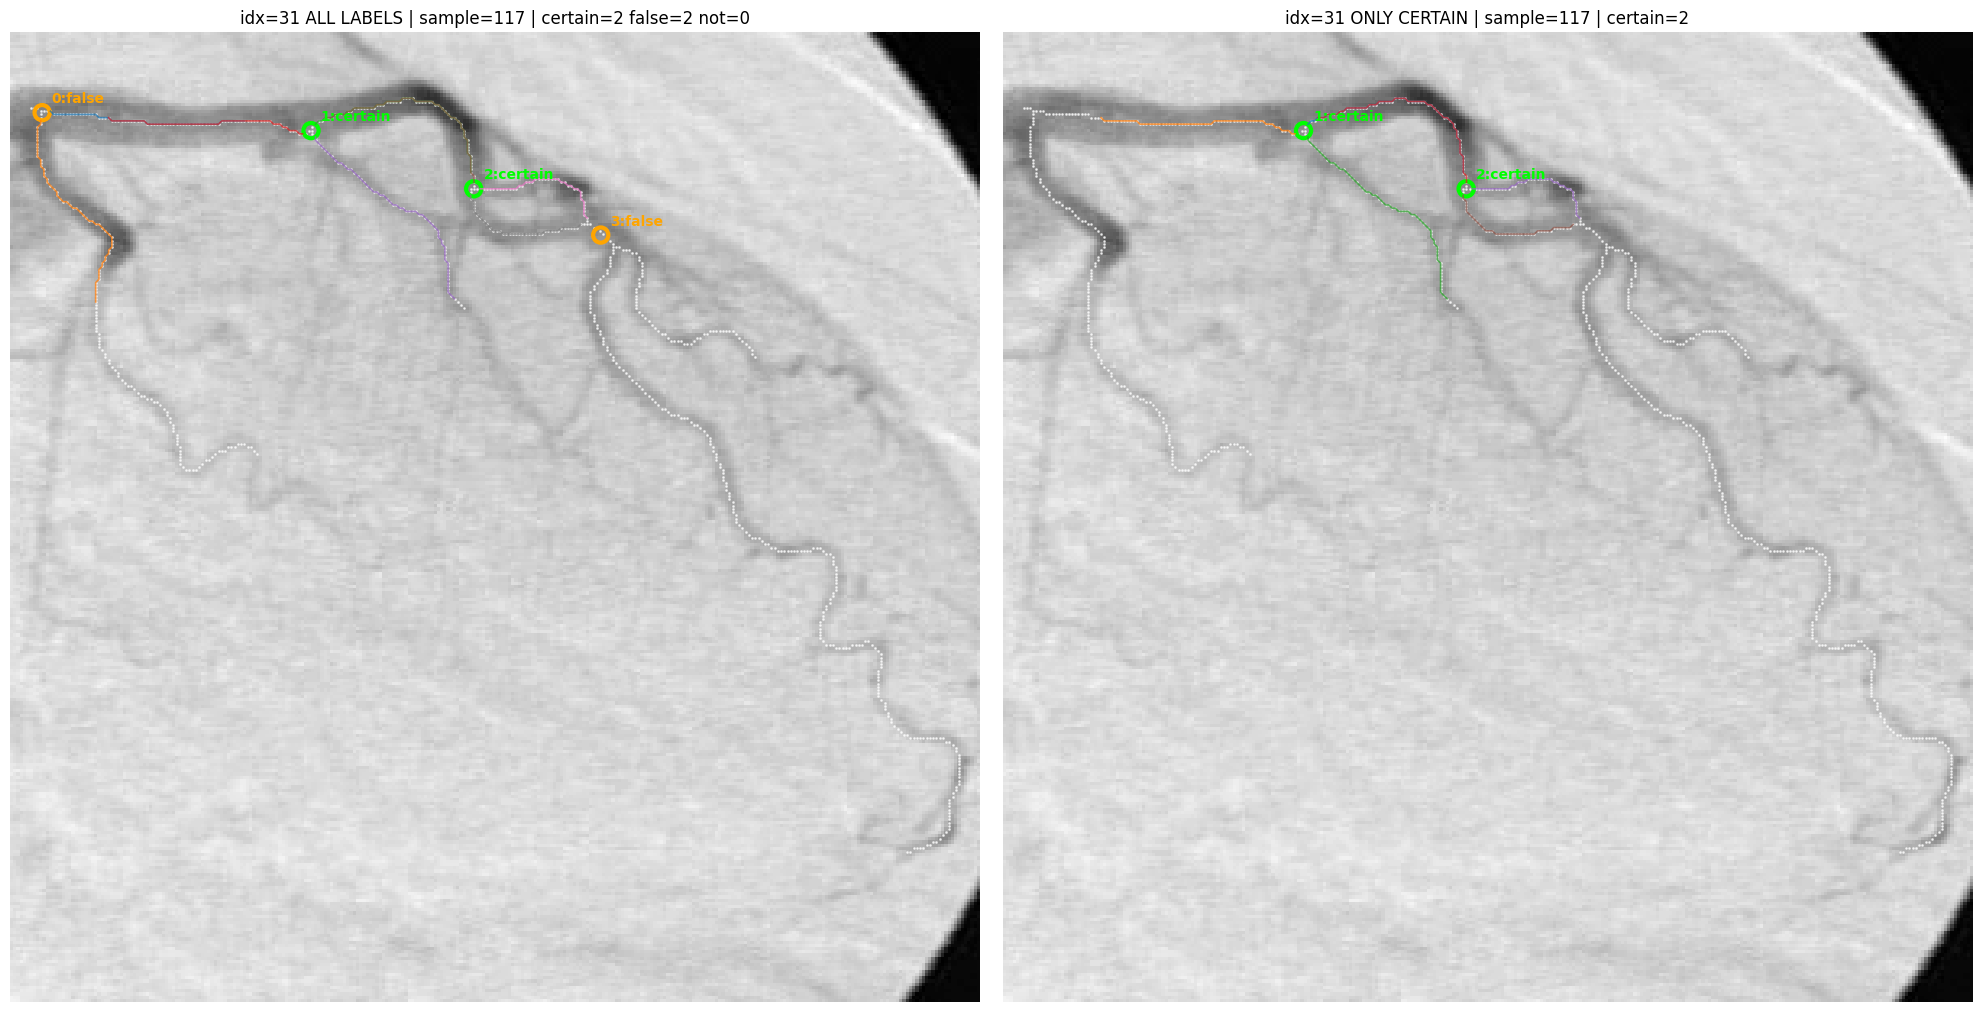

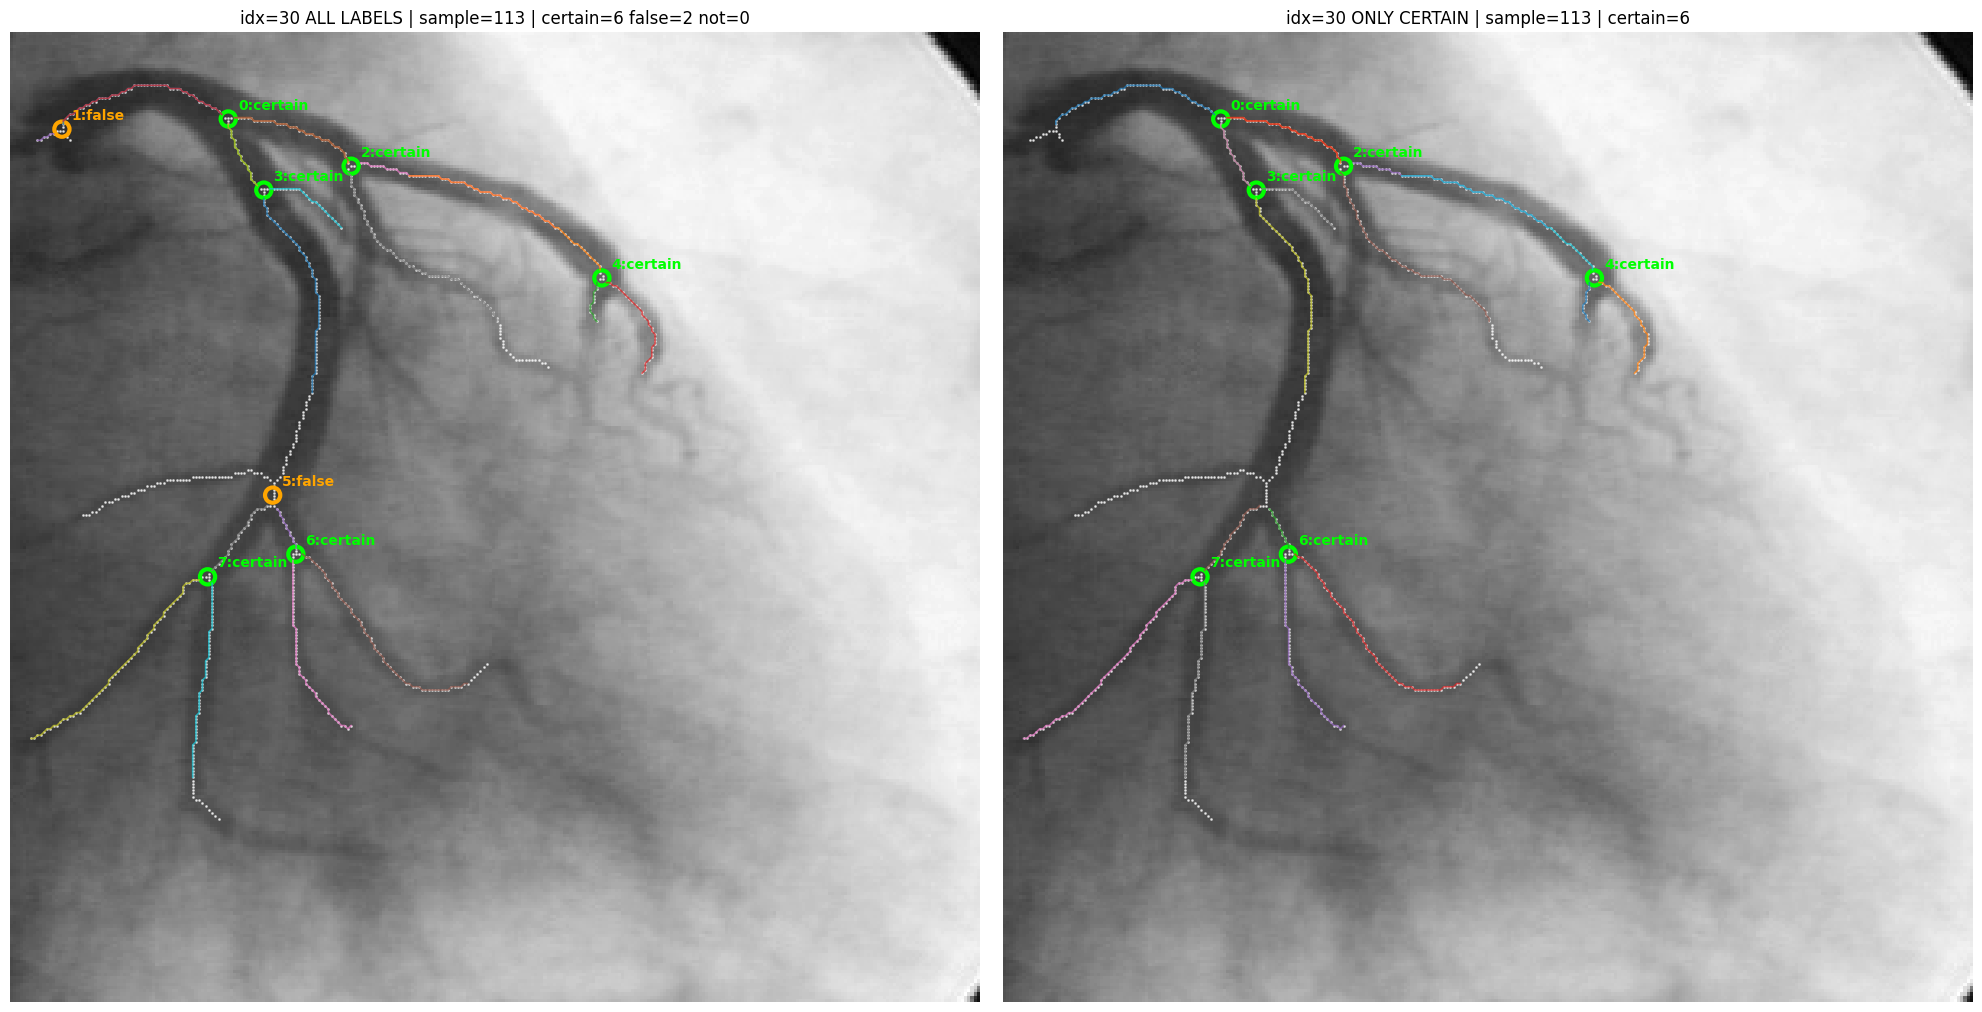

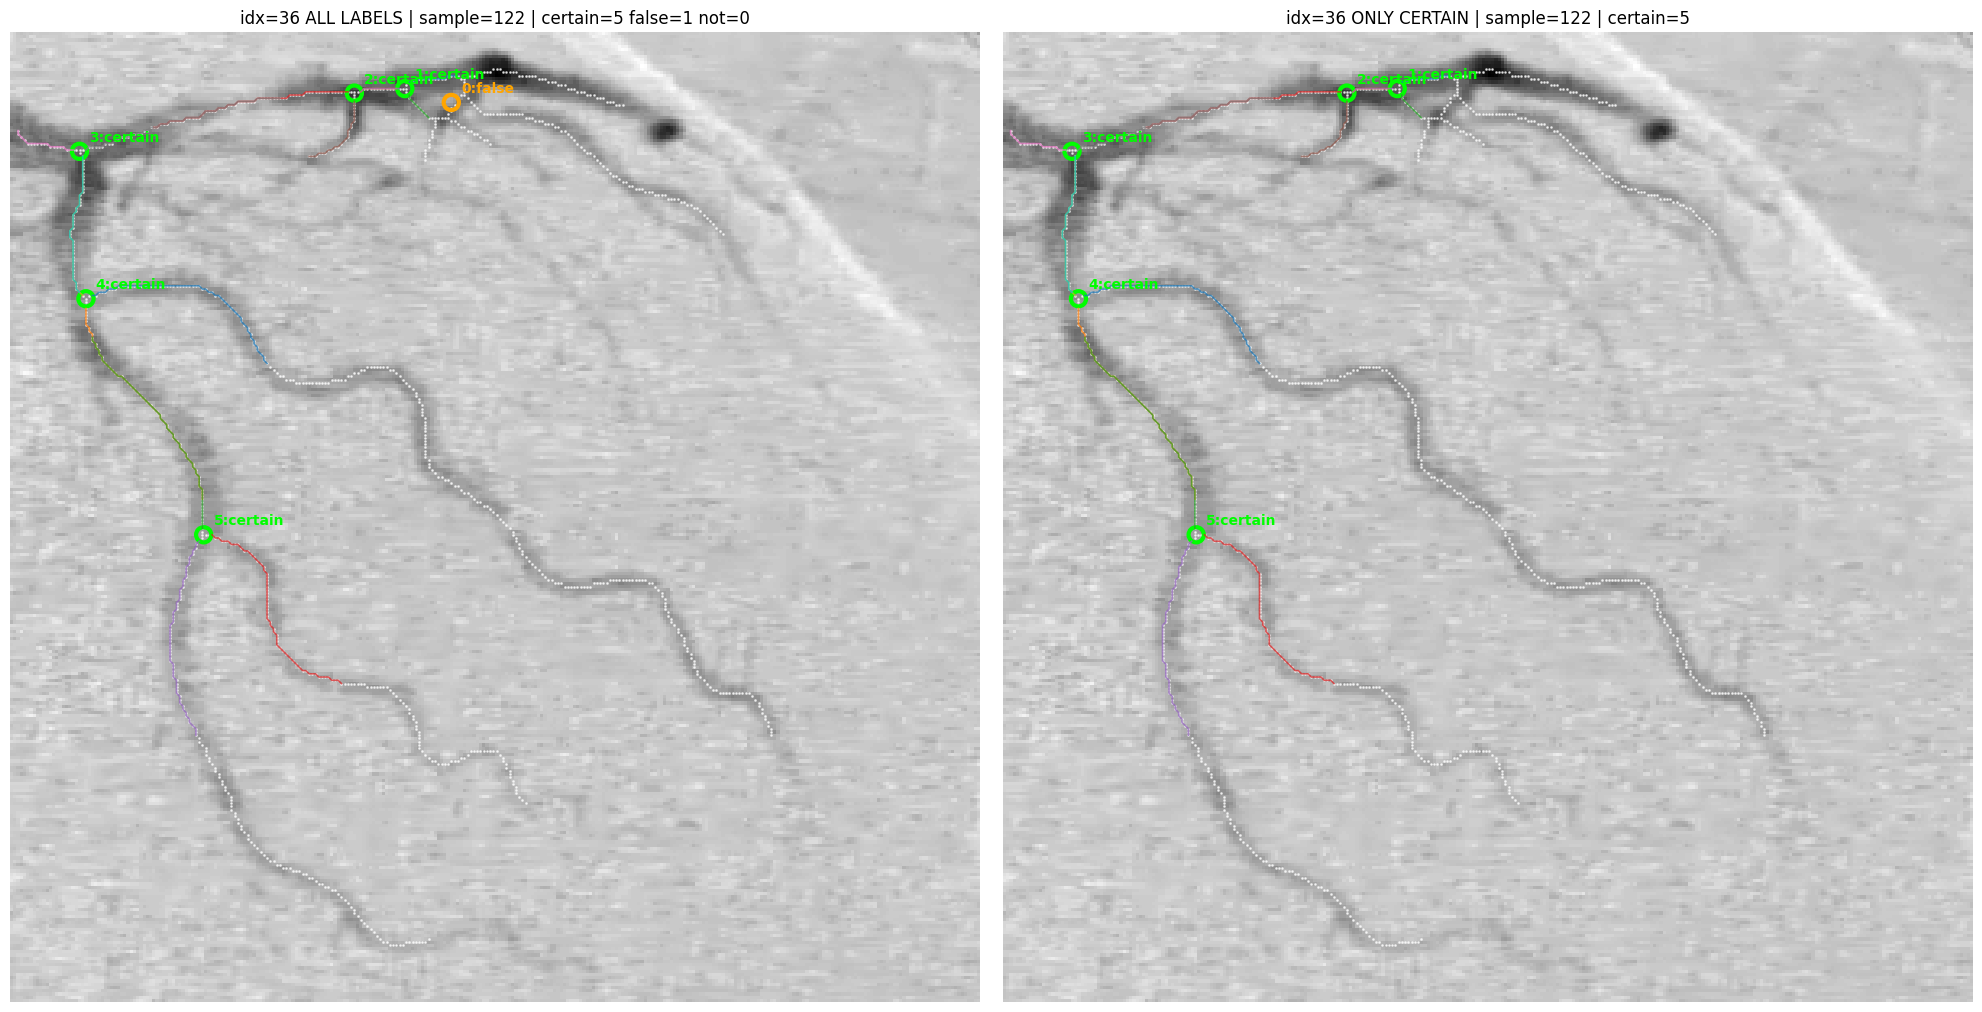

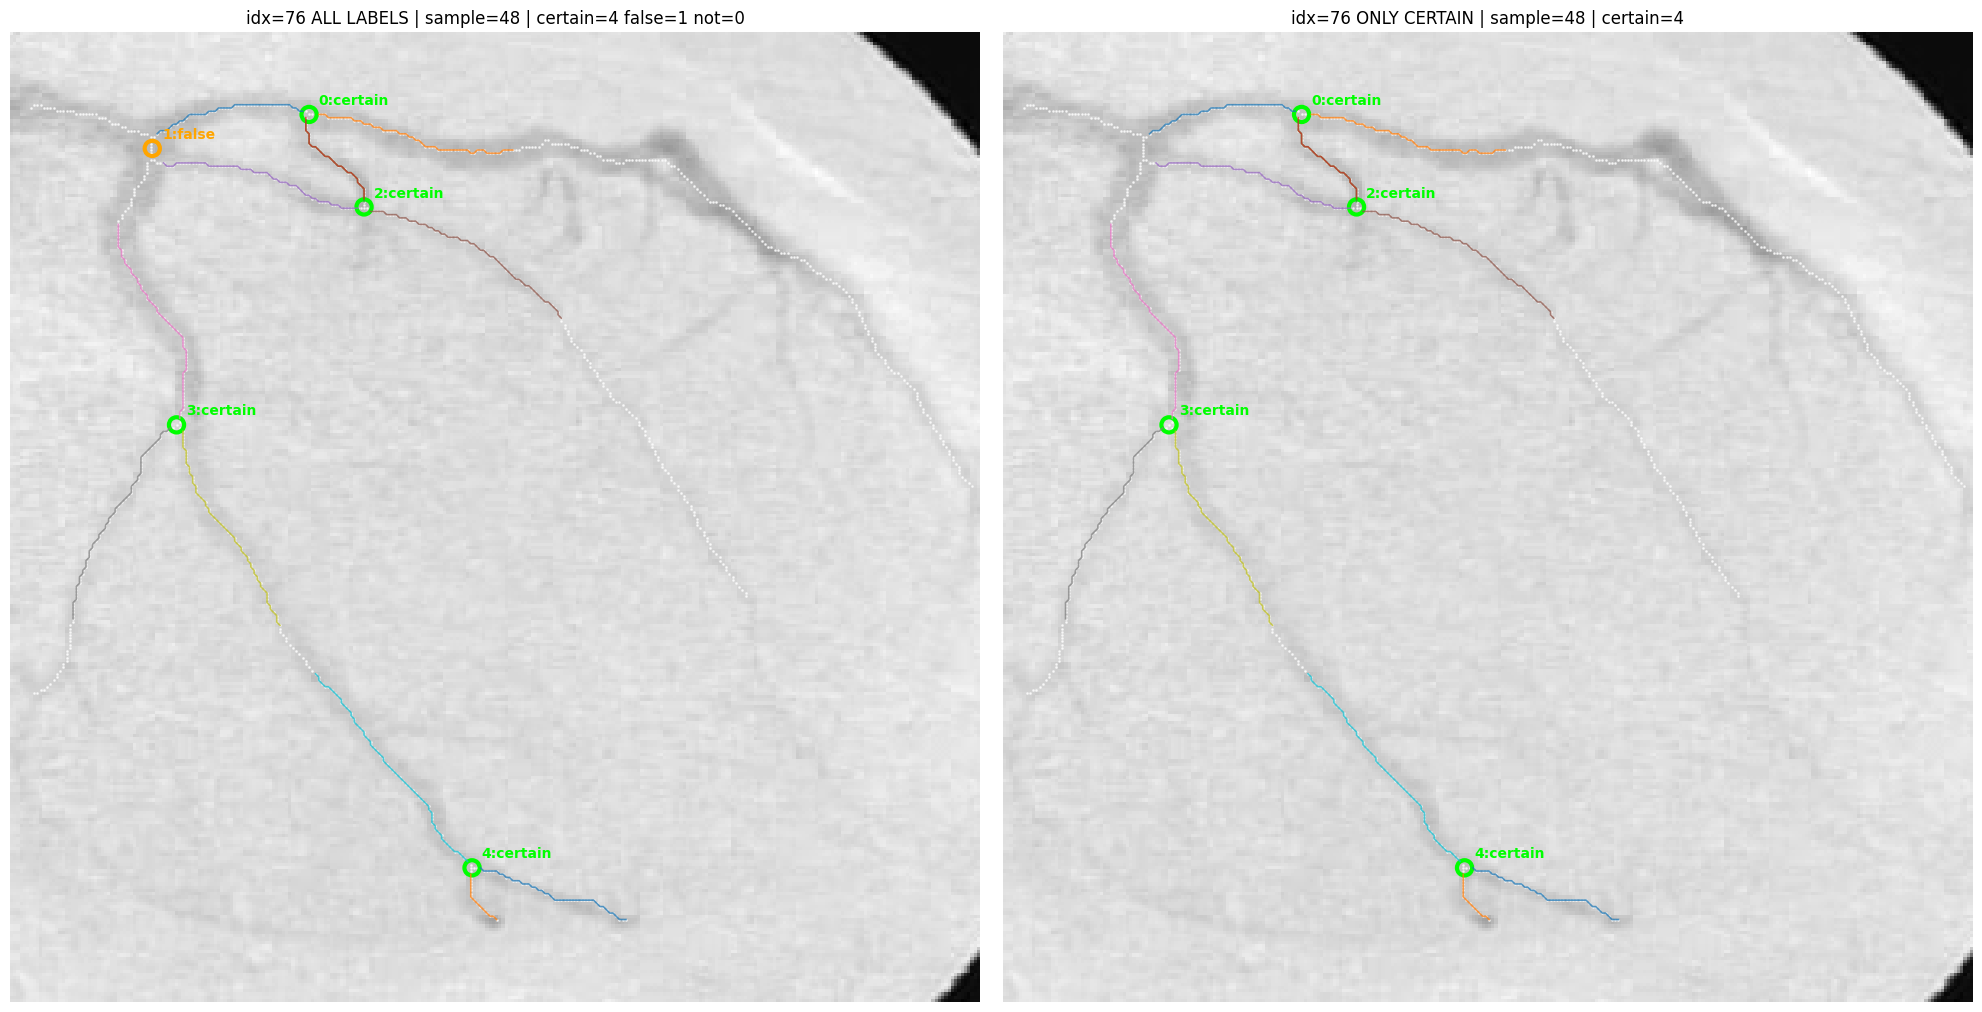

,sample_index,sample_id,certain,false,not,total
0,1,110,3,1,0,4
1,16,76,3,0,0,3
2,21,1,5,0,0,5
3,127,67,3,1,0,4
4,100,8,5,1,0,6
5,103,85,8,1,0,9
6,31,117,2,2,0,4
7,30,113,6,2,0,8
8,36,122,5,1,0,6
9,76,48,4,1,0,5


In [12]:
random.seed(RANDOM_SEED)

if len(samples) == 0:
    raise RuntimeError("Brak sampli.")

indices = list(range(len(samples)))
random.shuffle(indices)
indices = indices[: min(N_RANDOM_SAMPLES, len(indices))]

print("Selected sample indices:", indices)

batch_rows = []

for sample_idx in indices:
    out = run_pipeline_for_sample(sample_idx)
    counts = summarize_labels(out["results"])

    batch_rows.append(
        {
            "sample_index": sample_idx,
            "sample_id": out["row"]["id"],
            "certain": counts["certain"],
            "false": counts["false"],
            "not": counts["not"],
            "total": len(out["results"]),
        }
    )

    plot_junctions_pair(out, title_prefix=f"idx={sample_idx}")

df_batch = pd.DataFrame(batch_rows)
display(df_batch)